# 03B: Hierarchical Clustering

## Objective
Use Agglomerative (Hierarchical) clustering with reusable Kaggle data and feature cache.

In [12]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn scipy kagglehub

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
import kagglehub

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

Note: you may need to restart the kernel to use updated packages.


In [13]:
cwd = Path.cwd()
TASK_FOLDER = '03_stock_clustering_analysis'
if cwd.name == 'implementation':
    task_root = cwd.parent
elif cwd.name == TASK_FOLDER:
    task_root = cwd
elif (cwd / TASK_FOLDER).exists():
    task_root = cwd / TASK_FOLDER
else:
    task_root = cwd

DATA_DIR = task_root / 'data'
GRAPH_DIR = task_root / 'graph'
DATA_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

RAW_CACHE = DATA_DIR / 'sp500_raw.csv'
FEATURE_CACHE = DATA_DIR / 'clustering_features_latest.csv'

In [14]:
def create_clustering_features(stock_data: pd.DataFrame) -> pd.DataFrame:
    stock_data = stock_data.sort_values('date').reset_index(drop=True).copy()
    stock_data['volatility'] = stock_data['close'].pct_change().rolling(20).std()
    stock_data['avg_return'] = stock_data['close'].pct_change().rolling(20).mean()
    stock_data['avg_volume'] = stock_data['volume'].rolling(20).mean()
    stock_data['volume_volatility'] = stock_data['volume'].rolling(20).std() / stock_data['volume'].rolling(20).mean()
    stock_data['momentum'] = (stock_data['close'] - stock_data['close'].shift(20)) / stock_data['close'].shift(20)
    stock_data['price_range'] = (stock_data['high'] - stock_data['low']) / stock_data['close']
    stock_data['trend_strength'] = (stock_data['close'] - stock_data['low']) / (stock_data['high'] - stock_data['low'])
    stock_data['price_level'] = stock_data['close'] / 100
    stock_data['volume_to_price_ratio'] = stock_data['volume'] / stock_data['close']
    return stock_data

def load_raw_data() -> pd.DataFrame:
    if RAW_CACHE.exists():
        return pd.read_csv(RAW_CACHE)
    path = kagglehub.dataset_download('camnugent/sandp500')
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    df.to_csv(RAW_CACHE, index=False)
    return df

def load_feature_table(data: pd.DataFrame) -> pd.DataFrame:
    if FEATURE_CACHE.exists():
        return pd.read_csv(FEATURE_CACHE)
    processed = pd.concat([create_clustering_features(data[data['Name'] == s]) for s in data['Name'].unique()], ignore_index=True)
    clustering_data = processed.sort_values('date').drop_duplicates('Name', keep='last').dropna().reset_index(drop=True)
    clustering_data.to_csv(FEATURE_CACHE, index=False)
    return clustering_data

data = load_raw_data()
clustering_data = load_feature_table(data)
feature_cols = ['volatility','avg_return','avg_volume','volume_volatility','momentum','price_range','trend_strength','price_level','volume_to_price_ratio']
X = clustering_data[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(clustering_data[feature_cols].median(numeric_only=True))

# Reduce extreme-value dominance that can create unstable hierarchical splits.
for col in feature_cols:
    lower, upper = X[col].quantile([0.01, 0.99])
    X[col] = X[col].clip(lower=lower, upper=upper)

X_scaled = StandardScaler().fit_transform(X)
print(f'Samples={len(clustering_data)}, Features={len(feature_cols)}')

Samples=505, Features=9


In [15]:
# Grid search over linkage and k with stronger balance guardrails
n_samples = X_scaled.shape[0]
min_cluster_ratio = 0.03   # each cluster should contain at least 3% samples
max_cluster_ratio = 0.85   # avoid one dominant mega-cluster
candidates = []

for linkage_name in ['ward', 'complete']:
    for k in range(3, 11):
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
        labels = model.fit_predict(X_scaled)

        cluster_sizes_tmp = pd.Series(labels).value_counts()
        min_size = int(cluster_sizes_tmp.min())
        max_size = int(cluster_sizes_tmp.max())
        min_ratio = min_size / n_samples
        max_ratio = max_size / n_samples

        sil = silhouette_score(X_scaled, labels)
        dbi = davies_bouldin_score(X_scaled, labels)

        # Composite score: reward separation, penalize poor compactness and imbalance.
        balance_penalty = abs(max_ratio - 0.5)
        score = sil - 0.15 * dbi - 0.10 * balance_penalty

        candidates.append({
            'linkage': linkage_name,
            'k': k,
            'silhouette': sil,
            'dbi': dbi,
            'min_cluster_size': min_size,
            'max_cluster_size': max_size,
            'min_cluster_ratio': min_ratio,
            'max_cluster_ratio': max_ratio,
            'composite_score': score
        })

scores_df = pd.DataFrame(candidates)
valid_df = scores_df[
    (scores_df['min_cluster_ratio'] >= min_cluster_ratio) &
    (scores_df['max_cluster_ratio'] <= max_cluster_ratio)
].copy()

# Prefer stable/balanced partitions; fallback to best composite score if constraints are strict.
rank_source = valid_df if not valid_df.empty else scores_df
ranked_df = rank_source.sort_values('composite_score', ascending=False)

display(ranked_df.head(10))
best = ranked_df.iloc[0]
best_linkage, optimal_k = best['linkage'], int(best['k'])
print(
    f"Best linkage={best_linkage}, optimal_k={optimal_k}, "
    f"min_ratio={best['min_cluster_ratio']:.2%}, max_ratio={best['max_cluster_ratio']:.2%}, "
    f"composite={best['composite_score']:.4f}"
)

,linkage,k,silhouette,dbi,min_cluster_size,max_cluster_size,min_cluster_ratio,max_cluster_ratio,composite_score
1,ward,4,0.202695,1.683177,29,277,0.057426,0.548515,-0.054634
0,ward,3,0.211855,1.705672,29,339,0.057426,0.671287,-0.061124


Best linkage=ward, optimal_k=4, min_ratio=5.74%, max_ratio=54.85%, composite=-0.0546


cluster
0    137
1     29
2     62
3    277
Name: count, dtype: int64


,volatility,avg_return,avg_volume,volume_volatility,momentum,price_range,trend_strength,price_level,volume_to_price_ratio
cluster,,,,,,,,,
0,0.0204,0.0019,3.320189e+06,0.4256,0.0364,0.0337,0.3884,1.7094,6.655455e+04
1,0.0216,-0.0016,3.024173e+07,0.3716,-0.0323,0.0329,0.3126,0.4195,2.098670e+06
2,0.0234,-0.0045,5.121056e+06,0.5725,-0.0894,0.0419,0.3073,0.6758,1.594217e+05
3,0.0156,-0.0026,3.230232e+06,0.3681,-0.0515,0.0258,0.1869,0.9240,6.242136e+04


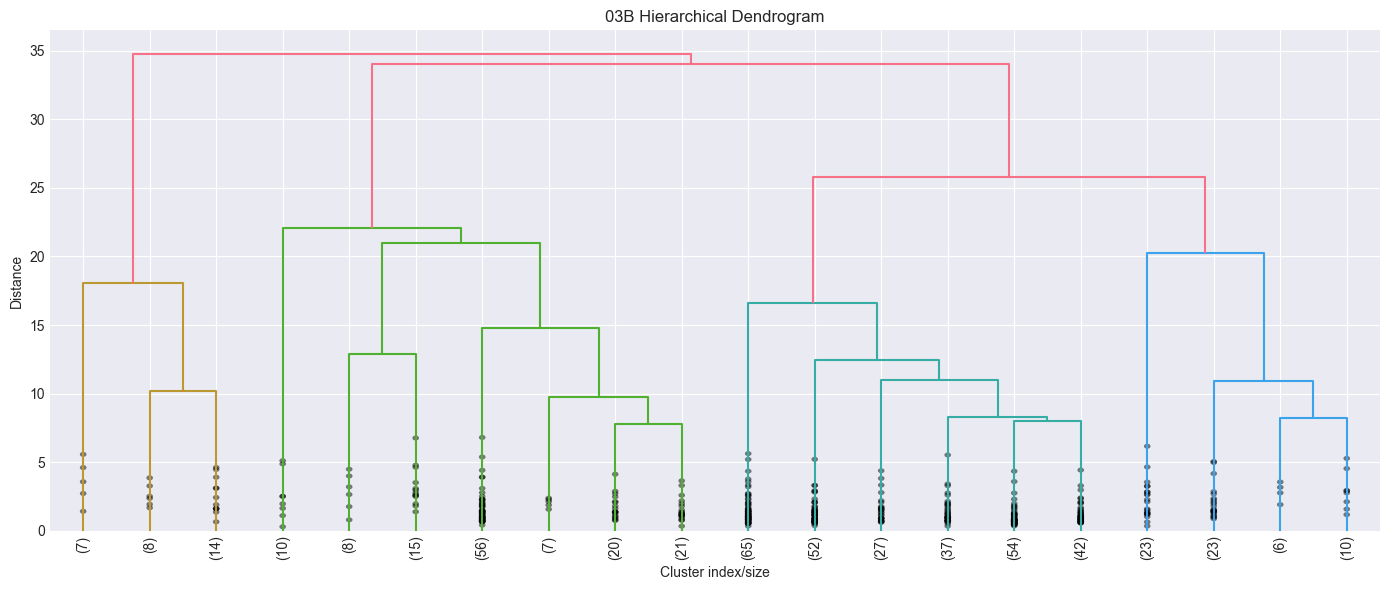

In [16]:
final_model = AgglomerativeClustering(n_clusters=optimal_k, linkage=best_linkage)
clustering_data['cluster'] = final_model.fit_predict(X_scaled)
cluster_summary = clustering_data.groupby('cluster')[feature_cols].mean().round(4)
cluster_sizes = clustering_data['cluster'].value_counts().sort_index()

print(cluster_sizes)
display(cluster_summary)

cluster_summary.to_csv(DATA_DIR / '03B_cluster_feature_summary.csv')
clustering_data[['Name', 'cluster'] + feature_cols].to_csv(DATA_DIR / '03B_stock_cluster_assignments.csv', index=False)

linkage_matrix = linkage(X_scaled, method=best_linkage)
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20, leaf_rotation=90, leaf_font_size=10, show_contracted=True, ax=ax)
ax.set_title('03B Hierarchical Dendrogram')
ax.set_xlabel('Cluster index/size'); ax.set_ylabel('Distance')
plt.tight_layout(); plt.savefig(GRAPH_DIR / '03B_01_dendrogram.png', dpi=300, bbox_inches='tight'); plt.show()

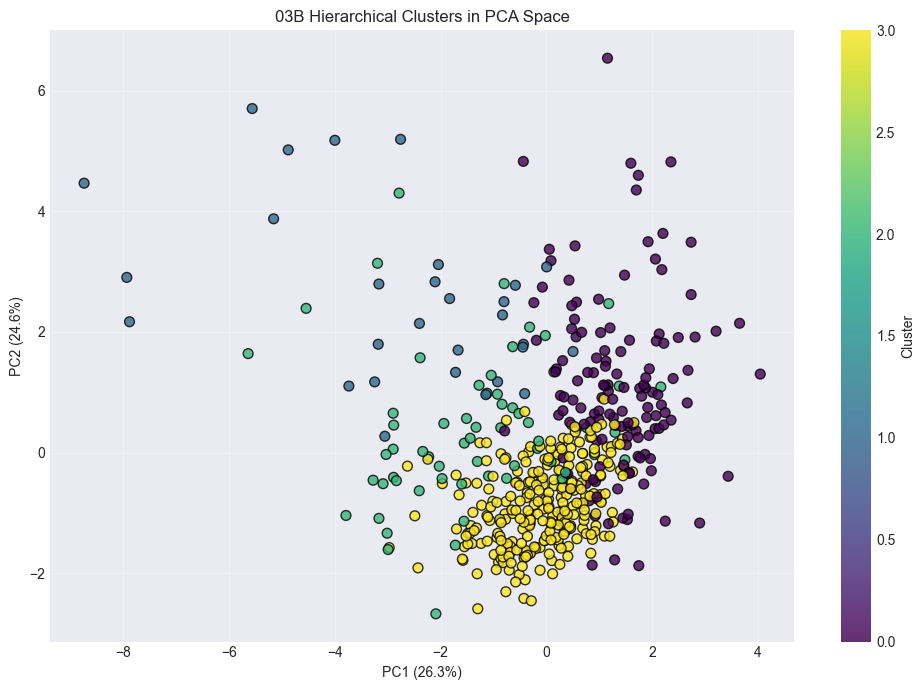

In [17]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_pca[:,0], X_pca[:,1], c=clustering_data['cluster'], cmap='viridis', s=50, edgecolor='black', alpha=0.8)
ax.set_title('03B Hierarchical Clusters in PCA Space')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})'); ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.grid(alpha=0.3); plt.colorbar(sc, label='Cluster')
plt.tight_layout(); plt.savefig(GRAPH_DIR / '03B_02_pca_scatter.png', dpi=300, bbox_inches='tight'); plt.show()

## Evaluation and Financial Interpretation
Use this section to assess statistical quality and practical finance meaning of clusters.

- Statistical checks: cluster concentration, feature differentiation profile.
- Finance checks: return-risk tradeoff, momentum dispersion, and liquidity context.
- Portfolio use: identify aggressive, defensive, and balanced baskets by regime.

=== Cluster Composition ===


,count,weight_pct
cluster,,
0,137,27.13
1,29,5.74
2,62,12.28
3,277,54.85


=== Cluster Feature Profile (mean) ===


,volatility,avg_return,avg_volume,volume_volatility,momentum,price_range,trend_strength,price_level,volume_to_price_ratio
cluster,,,,,,,,,
0,0.0204,0.0019,3.320189e+06,0.4256,0.0364,0.0337,0.3884,1.7094,6.655455e+04
1,0.0216,-0.0016,3.024173e+07,0.3716,-0.0323,0.0329,0.3126,0.4195,2.098670e+06
2,0.0234,-0.0045,5.121056e+06,0.5725,-0.0894,0.0419,0.3073,0.6758,1.594217e+05
3,0.0156,-0.0026,3.230232e+06,0.3681,-0.0515,0.0258,0.1869,0.9240,6.242136e+04


=== Risk-Return Lens ===


,avg_return,volatility,momentum,price_range,return_to_risk
cluster,,,,,
0,0.0019,0.0204,0.0364,0.0337,0.0956
1,-0.0016,0.0216,-0.0323,0.0329,-0.0727
2,-0.0045,0.0234,-0.0894,0.0419,-0.1916
3,-0.0026,0.0156,-0.0515,0.0258,-0.1633


[Insight] Cluster 0 has the strongest return-to-risk proxy in this snapshot.
[Insight] Cluster 3 is the most defensive regime by realized volatility.


C:\Users\25012923g\AppData\Local\Temp\ipykernel_21520\111405104.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eval_df, x=cluster_col, y='momentum', ax=axes[1, 1], palette='Set2')


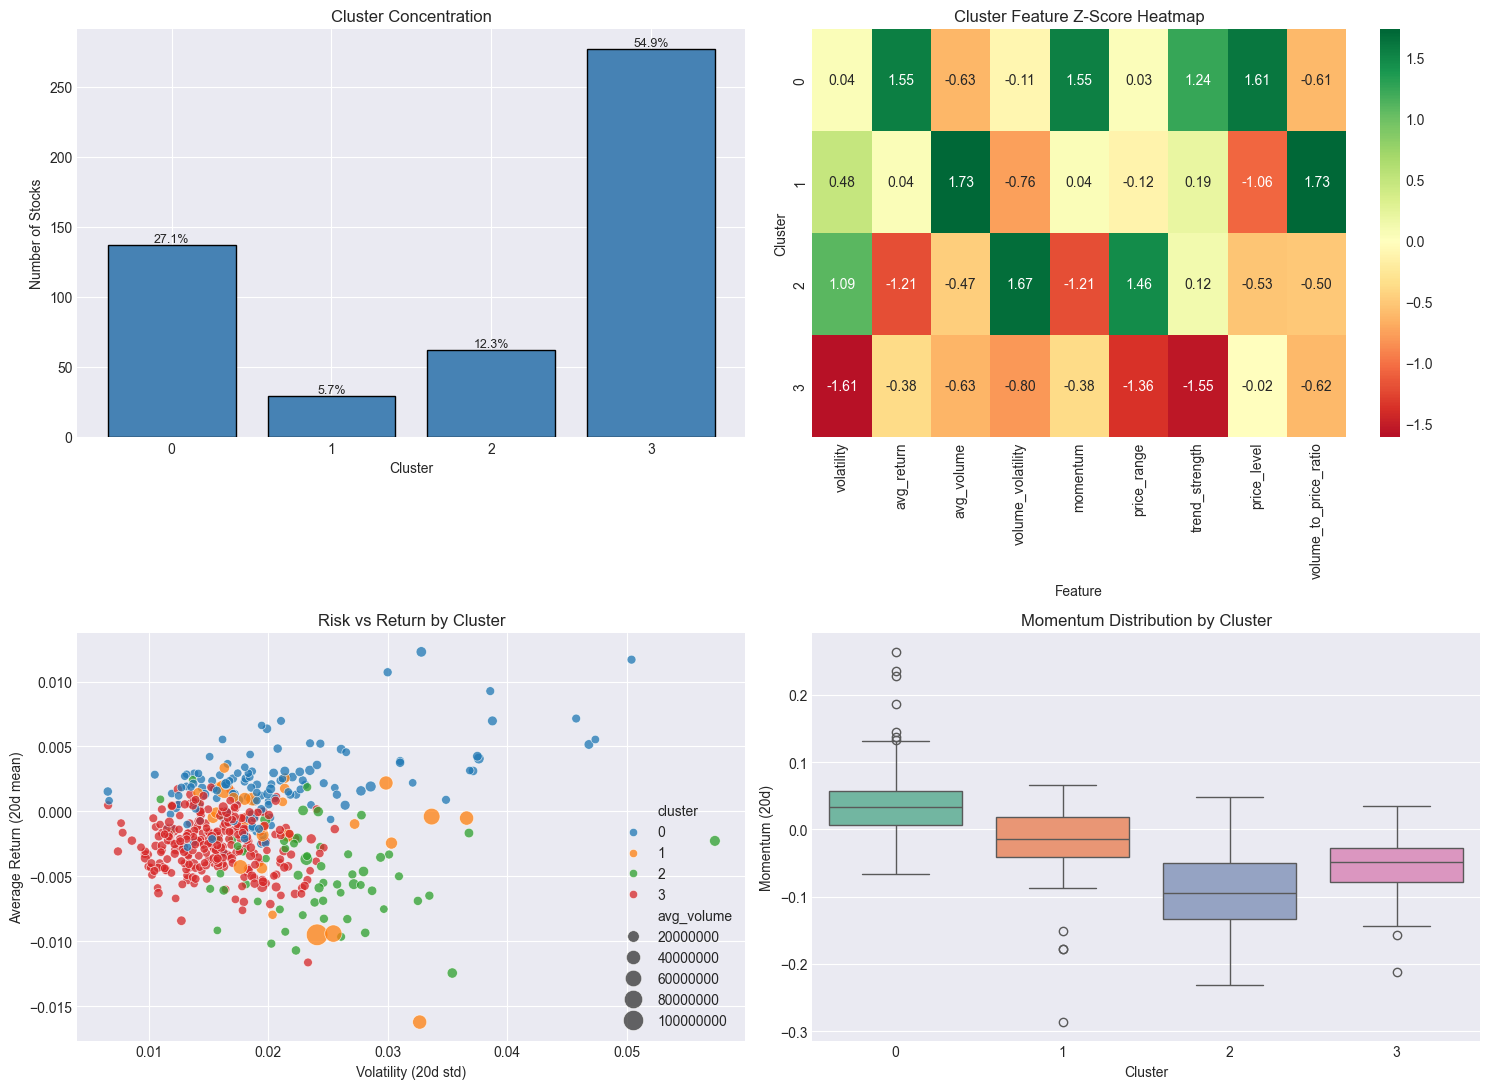

Saved evaluation dashboard: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\graph\03B_03_evaluation_dashboard.png


In [18]:
method_tag = '03B'
cluster_col = 'cluster'
eval_df = clustering_data.copy()

size_tbl = eval_df[cluster_col].value_counts().sort_index().rename('count').to_frame()
size_tbl['weight_pct'] = 100 * size_tbl['count'] / size_tbl['count'].sum()

profile_mean = eval_df.groupby(cluster_col)[feature_cols].mean()
profile_std = profile_mean.std(ddof=0).replace(0, np.nan)
profile_z = ((profile_mean - profile_mean.mean()) / profile_std).fillna(0.0)

risk_cols = ['avg_return', 'volatility', 'momentum', 'price_range']
risk_view = profile_mean[risk_cols].copy()
risk_view['return_to_risk'] = risk_view['avg_return'] / risk_view['volatility'].replace(0, np.nan)

print('=== Cluster Composition ===')
display(size_tbl.round(2))

print('=== Cluster Feature Profile (mean) ===')
display(profile_mean.round(4))

print('=== Risk-Return Lens ===')
display(risk_view.round(4))

if len(risk_view) >= 2:
    best_rr = risk_view['return_to_risk'].idxmax()
    defensive = risk_view['volatility'].idxmin()
    print(f'[Insight] Cluster {best_rr} has the strongest return-to-risk proxy in this snapshot.')
    print(f'[Insight] Cluster {defensive} is the most defensive regime by realized volatility.')

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

bars = axes[0, 0].bar(size_tbl.index.astype(str), size_tbl['count'], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Cluster Concentration')
axes[0, 0].set_xlabel('Cluster'); axes[0, 0].set_ylabel('Number of Stocks')
for i, b in enumerate(bars):
    pct = size_tbl['weight_pct'].iloc[i]
    axes[0, 0].text(b.get_x() + b.get_width()/2, b.get_height(), f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

sns.heatmap(profile_z, cmap='RdYlGn', center=0, annot=True, fmt='.2f', ax=axes[0, 1])
axes[0, 1].set_title('Cluster Feature Z-Score Heatmap')
axes[0, 1].set_xlabel('Feature'); axes[0, 1].set_ylabel('Cluster')

sns.scatterplot(data=eval_df, x='volatility', y='avg_return', hue=cluster_col, size='avg_volume', sizes=(35, 240),
                alpha=0.75, palette='tab10', ax=axes[1, 0])
axes[1, 0].set_title('Risk vs Return by Cluster')
axes[1, 0].set_xlabel('Volatility (20d std)'); axes[1, 0].set_ylabel('Average Return (20d mean)')

sns.boxplot(data=eval_df, x=cluster_col, y='momentum', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Momentum Distribution by Cluster')
axes[1, 1].set_xlabel('Cluster'); axes[1, 1].set_ylabel('Momentum (20d)')

plt.tight_layout()
dashboard_path = GRAPH_DIR / f'{method_tag}_03_evaluation_dashboard.png'
plt.savefig(dashboard_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved evaluation dashboard: {dashboard_path}')